# Computing the PCA of a Foreground Object
We show in our paper many figures with object parts colored like rainbows. These visualizations are obtained by computing a PCA of patch features on the foreground object. This is what we will compute in this tutorial! Let's start by loading some pre-requisites.

### Setup

Let's start by loading some pre-requisites and checking the DINOv3 repository location:
- `local` if `DINOV3_LOCATION` environment variable was set to work with a local version of DINOv3 repository;
- `github` if the code should be loaded via torch hub.

#### Installation Requirements

For the pathology workflow, you need additional dependencies:

```bash
# Install via micromamba
micromamba install h5py opencv geopandas

# Install via pip (not available in micromamba)
pip install openslide-python
```

See `requirements-pathology.txt` for full details.

In [ ]:
import pickle
import os
import urllib
import sys
from typing import Tuple, Dict, Optional

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import h5py

import torch
import torchvision.transforms.functional as TF
from sklearn.decomposition import PCA
from scipy import signal

# Add trident to path for using its WSI loaders
TRIDENT_PATH = "/home/nadim/Source/trident"
if TRIDENT_PATH not in sys.path:
    sys.path.insert(0, TRIDENT_PATH)

DINOV3_GITHUB_LOCATION = "facebookresearch/dinov3"

if os.getenv("DINOV3_LOCATION") is not None:
    DINOV3_LOCATION = os.getenv("DINOV3_LOCATION")
else:
    DINOV3_LOCATION = DINOV3_GITHUB_LOCATION

print(f"DINOv3 location set to {DINOV3_LOCATION}")
print(f"Trident path: {TRIDENT_PATH}")
print(f"h5py version: {h5py.__version__}")

### Model Loading
We load the DINOv3 ViT-L model. Feel free to try other DINOv3 models as well!

In [3]:
# examples of available DINOv3 models:
MODEL_DINOV3_VITS = "dinov3_vits16"
MODEL_DINOV3_VITSP = "dinov3_vits16plus"
MODEL_DINOV3_VITB = "dinov3_vitb16"
MODEL_DINOV3_VITL = "dinov3_vitl16"
MODEL_DINOV3_VITHP = "dinov3_vith16plus"
MODEL_DINOV3_VIT7B = "dinov3_vit7b16"

MODEL_NAME = MODEL_DINOV3_VITHP  # Using ViT-H16+ to match the checkpoint

# Load model from local checkpoint
CHECKPOINT_PATH = "/home/nadim/Downloads/dinov3h16/dinov3_vith16plus_pretrain_lvd1689m-7c1da9a5.pth"

model = torch.hub.load(
    repo_or_dir=DINOV3_LOCATION,
    model=MODEL_NAME,
    source="local" if DINOV3_LOCATION != DINOV3_GITHUB_LOCATION else "github",
    pretrained=True,
    weights=CHECKPOINT_PATH,  # Pass the local file path as weights
)
model.cuda()

Using cache found in /home/nadim/.cache/torch/hub/facebookresearch_dinov3_main


DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 1280, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (rope_embed): RopePositionEmbedding()
  (blocks): ModuleList(
    (0-31): 32 x SelfAttentionBlock(
      (norm1): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
      (attn): SelfAttention(
        (qkv): LinearKMaskedBias(in_features=1280, out_features=3840, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=1280, out_features=1280, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (norm2): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
      (mlp): SwiGLUFFN(
        (w1): Linear(in_features=1280, out_features=5120, bias=True)
        (w2): Linear(in_features=1280, out_features=5120, bias=True)
        (w3): Linear(in_features=5120, out_features=1280, bias=True)
      )
      (ls2): LayerScale()
    )
  )
  (norm): LayerNorm((

### Loading the Foreground Classifier from the Other Tutorial
For this tutorial, we use the classifier trained in the `foreground_segmentation` notebook. If you haven't already, have a look! Once you have trained your foreground / background classifier on patch features, you should be able to load it here. 

In [4]:
save_root = '.'
model_path = os.path.join(save_root, "fg_classifier.pkl")
with open(model_path, 'rb') as file:
    clf = pickle.load(file)

---
## Pathology Feature Loading from Trident H5 Files

The following cells implement functionality to load pre-extracted features and coordinates from Trident-processed pathology slides.

In [ ]:
def load_h5_from_trident(h5_path: str) -> Tuple[np.ndarray, np.ndarray, Dict]:
    """
    Load patch coordinates and features from a Trident-generated H5 file.
    
    Parameters
    ----------
    h5_path : str
        Path to the H5 file containing coords and features
        
    Returns
    -------
    coords : np.ndarray
        Array of patch coordinates (N, 2) where N is number of patches
    features : np.ndarray
        Array of feature vectors (N, D) where D is feature dimension
    metadata : dict
        Dictionary containing H5 file metadata and attributes
        
    Examples
    --------
    >>> coords, features, metadata = load_h5_from_trident("path/to/slide.h5")
    >>> print(f"Loaded {len(coords)} patches with {features.shape[1]}-dim features")
    """
    with h5py.File(h5_path, 'r') as f:
        # Load coords and features
        coords = f['coords'][:]
        features = f['features'][:]
        
        # Extract metadata from attributes
        metadata = {}
        for key in ['coords', 'features']:
            if key in f and hasattr(f[key], 'attrs'):
                metadata[key] = dict(f[key].attrs)
        
        # Add file-level info
        metadata['h5_keys'] = list(f.keys())
        metadata['num_patches'] = len(coords)
        metadata['feature_dim'] = features.shape[1] if len(features.shape) > 1 else 1
        
    return coords, features, metadata

### Test Feature 2: Load H5 from Trident

In [ ]:
# Test loading a sample H5 file
TEST_H5_PATH = "/media/nadim/Data/prostate-cancer-grade-assessment/trident_processedqc/20x_256px_0px_overlap/features_uni_v2/0005f7aaab2800f6170c399693a96917.h5"

print("Testing load_h5_from_trident()...")
coords, features, metadata = load_h5_from_trident(TEST_H5_PATH)

print(f"\n✓ Successfully loaded H5 file")
print(f"  Coordinates shape: {coords.shape}")
print(f"  Features shape: {features.shape}")
print(f"  Number of patches: {metadata['num_patches']}")
print(f"  Feature dimension: {metadata['feature_dim']}")
print(f"  H5 keys: {metadata['h5_keys']}")

# Display first few coordinates
print(f"\n  First 5 patch coordinates:")
for i in range(min(5, len(coords))):
    print(f"    Patch {i}: {coords[i]}")
    
# Feature statistics
print(f"\n  Feature statistics:")
print(f"    Mean: {features.mean():.4f}")
print(f"    Std: {features.std():.4f}")
print(f"    Min: {features.min():.4f}")
print(f"    Max: {features.max():.4f}")

In [ ]:
def load_wsi_and_extract_patches(
    wsi_path: str, 
    coords: np.ndarray, 
    patch_size: int = 256,
    target_mag: int = 20
) -> Tuple[list, Dict]:
    """
    Load a whole-slide image and extract patches at specified coordinates using Trident.
    
    Parameters
    ----------
    wsi_path : str
        Path to the WSI file (.tiff, .svs, etc.)
    coords : np.ndarray
        Array of patch coordinates (N, 2) at level 0
    patch_size : int
        Size of patches to extract (default: 256)
    target_mag : int
        Target magnification for extraction (default: 20x)
        
    Returns
    -------
    patches : list
        List of PIL Image patches
    wsi_info : dict
        Dictionary containing WSI metadata (dimensions, magnification, etc.)
        
    Examples
    --------
    >>> patches, info = load_wsi_and_extract_patches("slide.tiff", coords)
    >>> print(f"Extracted {len(patches)} patches from {info['filename']}")
    """
    # Import from top-level trident to avoid circular imports
    from trident import load_wsi
    
    # Load WSI using trident factory - disable lazy_init to load immediately
    wsi = load_wsi(wsi_path, lazy_init=False)
    
    # Store WSI info
    wsi_info = {
        'filename': os.path.basename(wsi_path),
        'width': wsi.width,
        'height': wsi.height,
        'magnification': wsi.mag,
        'num_coords': len(coords),
        'patch_size': patch_size,
        'target_mag': target_mag
    }
    
    # Create patcher with the given coordinates
    # Set pil=True to return PIL Images instead of numpy arrays
    patcher = wsi.create_patcher(
        patch_size=patch_size,
        src_mag=wsi.mag,
        dst_mag=target_mag,
        custom_coords=coords,
        coords_only=False,  # We want to extract actual patches
        pil=True  # Return PIL Images (not numpy arrays)
    )
    
    # Extract all patches
    patches = []
    for i, (patch, x, y) in enumerate(patcher):
        patches.append(patch)
        
    print(f"Extracted {len(patches)} patches from {wsi_info['filename']}")
    
    return patches, wsi_info

### Test Feature 3: Load WSI and Extract Patches

In [ ]:
# Test loading WSI and extracting patches
TEST_WSI_PATH = "/media/nadim/Data/prostate-cancer-grade-assessment/train_images/0005f7aaab2800f6170c399693a96917.tiff"

print("Testing load_wsi_and_extract_patches()...")

# Extract first 10 patches as a test (to avoid loading all patches)
test_coords = coords[:10]
patches, wsi_info = load_wsi_and_extract_patches(
    TEST_WSI_PATH, 
    test_coords, 
    patch_size=256, 
    target_mag=20
)

print(f"\n✓ Successfully extracted patches")
print(f"  WSI filename: {wsi_info['filename']}")
print(f"  WSI dimensions: {wsi_info['width']} x {wsi_info['height']}")
print(f"  WSI magnification: {wsi_info['magnification']}x")
print(f"  Number of patches extracted: {len(patches)}")
print(f"  Patch size: {patches[0].size if patches else 'N/A'}")

# Visualize first few patches
if patches:
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle("Sample Extracted Patches", fontsize=16)
    
    for idx, (ax, patch) in enumerate(zip(axes.flat, patches)):
        ax.imshow(patch)
        ax.set_title(f"Patch {idx}\n{coords[idx]}", fontsize=8)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
print("\n✓ Feature 3 test completed successfully!")

### Loading an Image and Applying the Right Transform
Let's load an image and process it in order to make it a multiple of the patch size.

In [6]:
PATCH_SIZE = 16
IMAGE_SIZE = 768

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

image_uri = "https://dl.fbaipublicfiles.com/dinov3/notebooks/pca/test_image.jpg"

def load_image_from_url(url: str) -> Image:
    with urllib.request.urlopen(url) as f:
        return Image.open(f).convert("RGB")
     
# image resize transform to dimensions divisible by patch size
def resize_transform(
    mask_image: Image,
    image_size: int = IMAGE_SIZE,
    patch_size: int = PATCH_SIZE,
) -> torch.Tensor:
    w, h = mask_image.size
    h_patches = int(image_size / patch_size)
    w_patches = int((w * image_size) / (h * patch_size))
    return TF.to_tensor(TF.resize(mask_image, (h_patches * patch_size, w_patches * patch_size)))


image = load_image_from_url(image_uri)
image_resized = resize_transform(image)
print(f"Original Image Size {image.size}")
print(f"Original Image Size {image_resized.size()}")   
image_resized_norm = TF.normalize(image_resized, mean=IMAGENET_MEAN, std=IMAGENET_STD)

Original Image Size (1134, 2016)
Original Image Size torch.Size([3, 768, 432])


### Model Forward
Given the input image, we compute local features:

In [5]:
MODEL_TO_NUM_LAYERS = {
    MODEL_DINOV3_VITS: 12,
    MODEL_DINOV3_VITSP: 12,
    MODEL_DINOV3_VITB: 12,
    MODEL_DINOV3_VITL: 24,
    MODEL_DINOV3_VITHP: 32,
    MODEL_DINOV3_VIT7B: 40,
}

n_layers = MODEL_TO_NUM_LAYERS[MODEL_NAME]

with torch.inference_mode():
    with torch.autocast(device_type='cuda', dtype=torch.float32):
        feats = model.get_intermediate_layers(image_resized_norm.unsqueeze(0).cuda(), n=range(n_layers), reshape=True, norm=True)
        x = feats[-1].squeeze().detach().cpu()
        dim = x.shape[0]
        x = x.view(dim, -1).permute(1, 0)

### Computing Foreground Probability
Let's now pass all those features through our foreground classifier, extract probabilities, and reshape.

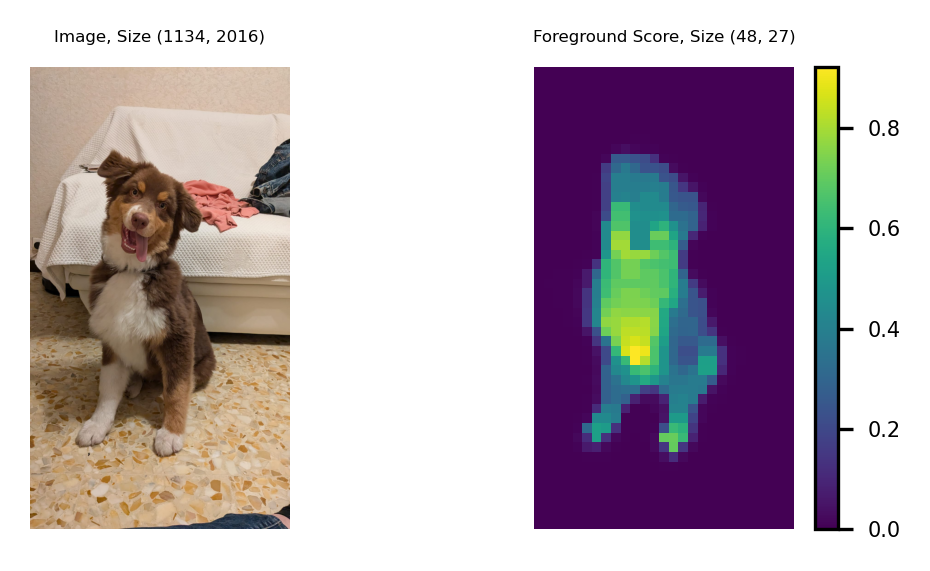

In [6]:
h_patches, w_patches = [int(d / PATCH_SIZE) for d in image_resized.shape[1:]]

fg_score = clf.predict_proba(x)[:, 1].reshape(h_patches, w_patches)
fg_score_mf = torch.from_numpy(signal.medfilt2d(fg_score, kernel_size=3))

plt.rcParams.update({
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "axes.labelsize": 5,
    "axes.titlesize": 4,
})

plt.figure(figsize=(4, 2), dpi=300)
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.axis('off')
plt.title(f"Image, Size {image.size}")
plt.subplot(1, 2, 2)
plt.imshow(fg_score_mf)
plt.title(f"Foreground Score, Size {tuple(fg_score_mf.shape)}")
plt.colorbar()
plt.axis('off')
plt.show()

### Extracting Foreground Patches
We find the patches with positive classifier output, in order to fit the PCA only on the foreground.

In [7]:
foreground_selection = fg_score_mf.view(-1) > 0.5
fg_patches = x[foreground_selection]

### Fitting the PCA
We use 3 components, and use whitening. 

In [8]:
pca = PCA(n_components=3, whiten=True)
pca.fit(fg_patches)

,n_components,3
,copy,True
,whiten,True
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


### Applying the PCA, and Masking Background
Finally, we project the features using the PCA, and apply a mask to set the background to black.

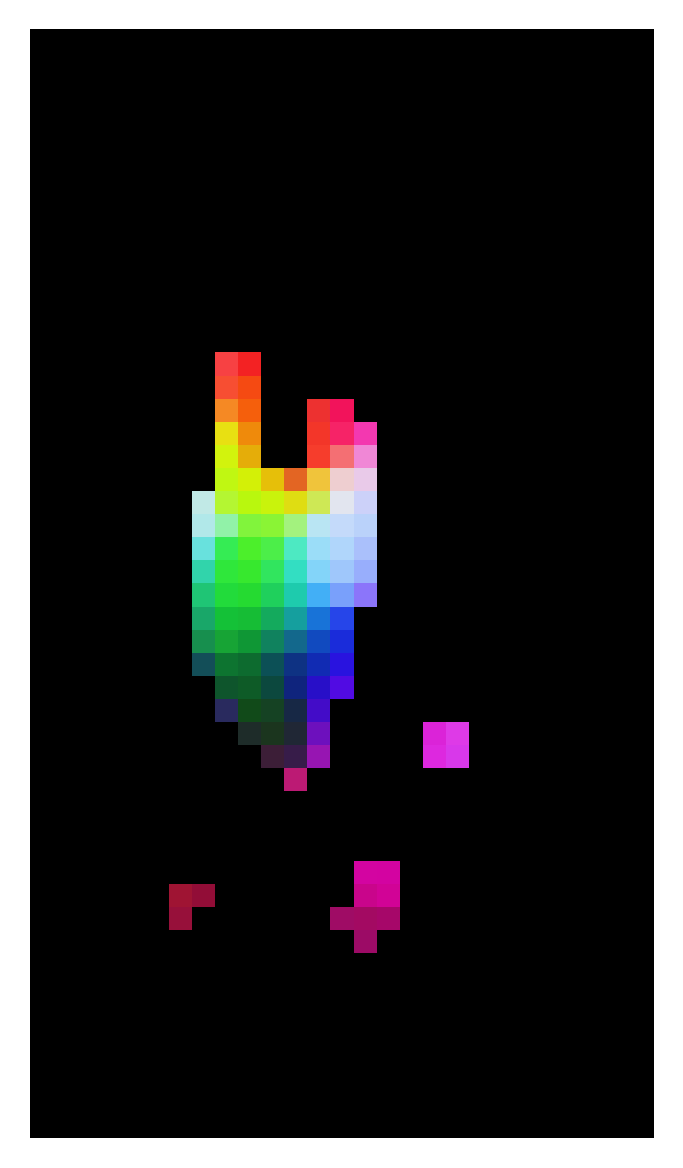

In [9]:
# apply the PCA, and then reshape
projected_image = torch.from_numpy(pca.transform(x.numpy())).view(h_patches, w_patches, 3)

# multiply by 2.0 and pass through a sigmoid to get vibrant colors 
projected_image = torch.nn.functional.sigmoid(projected_image.mul(2.0)).permute(2, 0, 1)

# mask the background using the fg_score_mf
projected_image *= (fg_score_mf.unsqueeze(0) > 0.5)

# enjoy
plt.figure(dpi=300)
plt.imshow(projected_image.permute(1, 2, 0))
plt.axis('off')
plt.show()